In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Display dataset description
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [2]:
# Display the first 5 rows of the DataFrame
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Display the sum of null values for each column
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [5]:
# Display descriptive statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [7]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 0.53
Mean Squared Error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
R-squared (R²): 0.58


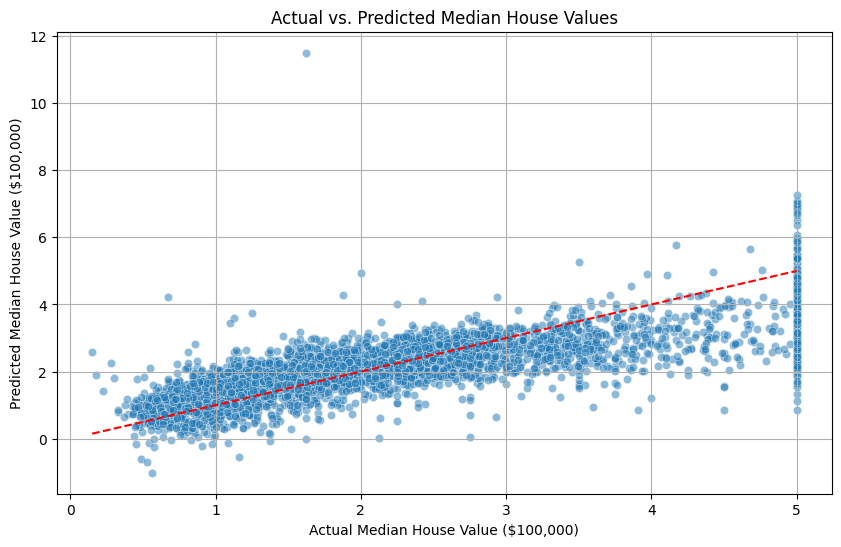

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for perfect prediction
plt.xlabel("Actual Median House Value ($100,000)")
plt.ylabel("Predicted Median House Value ($100,000)")
plt.title("Actual vs. Predicted Median House Values")
plt.grid(True)
plt.show()

### Make Predictions on New Data

In [10]:
def predict_house_value(med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude):
    """
    Predicts the median house value for a given set of input features.
    """
    # Create a DataFrame from the input features, ensuring column order matches training data
    input_data = pd.DataFrame([[med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude]],
                              columns=X.columns) # Use X.columns to ensure correct order and names

    # Make prediction
    prediction = model.predict(input_data)[0]

    # Convert prediction back to actual dollars (since target was in $100,000s)
    predicted_value_dollars = prediction * 100000

    return predicted_value_dollars

# Example usage:
# Let's use the mean values from our dataset as an example input
example_input = df.drop('MedHouseVal', axis=1).mean().tolist()

# Unpack the list into function arguments
predicted_price = predict_house_value(*example_input)

print(f"Predicted Median House Value for average features: ${predicted_price:,.2f}")

# You can also try with custom values:
# custom_price = predict_house_value(med_inc=5.0, house_age=30.0, ave_rooms=6.0,
#                                    ave_bedrms=1.0, population=1500.0, ave_occup=3.0,
#                                    latitude=34.0, longitude=-118.0)
# print(f"Predicted Median House Value for custom features: ${custom_price:,.2f}")

Predicted Median House Value for average features: $206,786.23


## Project Report: California House Price Prediction using Linear Regression

### 1. Introduction

This project aimed to develop and evaluate a Linear Regression model for predicting median house values in California using the California Housing dataset. The process followed a standard machine learning workflow, encompassing data loading, exploratory data analysis (EDA), data preprocessing, model training, evaluation, and a demonstration of its predictive capability.

### 2. Data Loading and Initial Exploration

- The California Housing dataset was loaded using `fetch_california_housing` from `sklearn.datasets`.
- The dataset contains **20,640 instances** with **8 numeric features** and one target variable: `MedHouseVal` (Median House Value).
- The target variable represents median house values in hundreds of thousands of dollars ($100,000).
- The first 5 rows of the DataFrame were displayed to get an initial look at the data structure.

### 3. Exploratory Data Analysis (EDA) & Preprocessing

- **Missing Values and Data Types:**
    - `df.info()` and `df.isnull().sum()` were used to check for missing values and data types.
    - **Outcome:** No missing values were found across any features or the target variable. All features and the target were confirmed to be of `float64` data type, which is suitable for numerical analysis with Linear Regression.
- **Descriptive Statistics:**
    - `df.describe()` provided a statistical summary of the dataset, including count, mean, standard deviation, min, max, and quartiles for each numerical column. This helped in understanding the distribution and range of each feature.

### 4. Data Splitting

- **Feature and Target Separation:**
    - The features (X) were separated from the target variable (y), where `y` is `MedHouseVal`.
- **Train-Test Split:**
    - The dataset was split into training and testing sets to evaluate the model's performance on unseen data.
    - An **80% training set** and **20% testing set** split was used, with `random_state=42` for reproducibility.
    - **Outcome:**
        - `X_train` shape: (16512, 8)
        - `X_test` shape: (4128, 8)
        - `y_train` shape: (16512,)
        - `y_test` shape: (4128,)

### 5. Model Training

- **Model Initialization:**
    - A `LinearRegression` model from `scikit-learn` was initialized.
- **Model Training:**
    - The model was trained using the `X_train` (features) and `y_train` (target) data.
    - **Outcome:** The Linear Regression model was successfully trained on the provided data.

### 6. Model Evaluation

- **Predictions:**
    - Predictions (`y_pred`) were generated on the `X_test` set.
- **Evaluation Metrics:**
    - The model's performance was assessed using standard regression metrics:
        - **Mean Absolute Error (MAE): 0.53** (This implies an average prediction error of $53,000).
        - **Mean Squared Error (MSE): 0.56**
        - **Root Mean Squared Error (RMSE): 0.75** (This implies an average prediction error of $75,000, which is in the same units as the target variable).
        - **R-squared (R²): 0.58** (The model explains approximately 58% of the variance in median housing prices, indicating a moderate fit).
- **Visual Assessment:**
    - A scatter plot of actual vs. predicted values was generated. A red dashed line representing perfect prediction was included for visual comparison. This plot helps to identify any systematic biases or patterns in the model's predictions.

### 7. Model Demonstration

- **`predict_house_value` Function:**
    - A Python function `predict_house_value` was created to enable users to input specific feature values and receive a predicted median house value in dollars.
- **Example Usage:**
    - The function was demonstrated using the **mean values** of the dataset's features as input.
    - **Outcome:** For the average feature values, the model predicted a median house value of **$206,786.23**.

### 8. Unresolved Questions/Tasks and Suggested Improvements

While the current Linear Regression model provides a baseline for house price prediction, there are several avenues for further improvement and task completion:

-   **Further Model Improvements:**
    -   **Feature Engineering:** Create new features from existing ones (e.g., polynomial features, interaction terms) to capture more complex relationships.
    -   **Exploring More Advanced Models:** Investigate other regression models such as Ridge, Lasso, ElasticNet, Random Forests, Gradient Boosting Machines (e.g., XGBoost, LightGBM), or Neural Networks.
    -   **Hyperparameter Tuning:** Optimize the hyperparameters of the chosen model(s) using techniques like GridSearchCV or RandomizedSearchCV.
    -   **Feature Scaling:** Apply feature scaling (e.g., StandardScaler, MinMaxScaler) to features, which can improve the performance of many machine learning algorithms, especially those sensitive to feature magnitudes (like Linear Regression with regularization).
    -   **Outlier Detection and Handling:** Identify and address outliers in the dataset, which can disproportionately influence model training.
-   **Deliverables:**
    -   **Jupyter Notebook:** The notebook containing all the code and plots is in progress.
    -   **PDF Report:** A comprehensive 2-4 page PDF report summarizing the EDA, model details, evaluation metrics, and improvement ideas still needs to be finalized.
    -   **Saved Model:** Optionally, save the trained model as a pickle file for future deployment.
    -   **Small UI Script:** The `predict_house_value` function partially addresses this, but a more comprehensive interactive UI could be developed.

### Conclusion

The Linear Regression model successfully established a baseline for predicting California house prices, achieving an R-squared of 0.58 and an RMSE of $75,000. While these results indicate a moderate fit, significant potential exists for enhancing model performance through further advanced techniques and thorough investigation of the dataset.